In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score


In [2]:
# --- utilities ---
def random_orthogonal(D, rng):
    # QR分解でランダム直交行列を作る
    A = rng.normal(size=(D, D))
    Q, R = np.linalg.qr(A)
    # 符号調整（任意だが安定のため）
    Q *= np.sign(np.diag(R))
    return Q

def make_blobs_lowrank_means(n_classes, r, mean_scale, rng):
    # r次元にクラス平均を置く（互いにそこそこ離す）
    means = rng.normal(size=(n_classes, r))
    means = means / np.linalg.norm(means, axis=1, keepdims=True)
    means = means * mean_scale
    return means

def plot_scree(pca, title="Scree"):
    evr = pca.explained_variance_ratio_
    cum = np.cumsum(evr)
    fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(np.arange(1, len(evr)+1), cum)
    ax.set_xlabel("Number of components")
    ax.set_ylabel("Cumulative explained variance ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.show()

def plot_tsne(Z, y, title="t-SNE"):
    fig, ax = plt.subplots(figsize=(6,5))
    sc = ax.scatter(Z[:,0], Z[:,1], c=y, s=8)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

def knn_cv_accuracy(X, y, k=5):
    clf = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(clf, X, y, cv=5)
    return scores.mean()

# --- dataset generators ---
def dataset_success_flat_scree(
    n_per_class=300, n_classes=5, D=2000, r=30,
    noise_sigma=1.0, mean_scale=1.0, seed=0
):
    """
    成功例：
    - ノイズが支配的で寄与率はなだらか
    - ただしクラス平均差は r 次元の部分空間に集中（低ランク）
    - 直交回転で軸合わせを隠す
    """
    rng = np.random.default_rng(seed)
    N = n_per_class * n_classes
    y = np.repeat(np.arange(n_classes), n_per_class)

    # 低ランク部分空間に信号（クラス平均との差）
    means_r = make_blobs_lowrank_means(n_classes, r, mean_scale, rng)

    # 埋め込み（D次元へ）
    X = rng.normal(scale=noise_sigma, size=(N, D))  # 等方ノイズ（寄与率をフラットにする主役）
    X[:, :r] += means_r[y]  # まずは前r次元にだけ差を入れる

    # 直交回転して信号の方向を見えにくくする
    Q = random_orthogonal(D, rng)
    X = X @ Q
    return X, y

def dataset_failure_flat_scree(
    n_per_class=300, n_classes=5, D=2000,
    noise_sigma=1.0, mean_scale=1.0, seed=1
):
    """
    失敗例：
    - ノイズは同程度（寄与率は同じくなだらか）
    - クラス平均との差は D 次元全体に均等に拡散（高次元に“薄く”広がる）
    - PCAで上位kに切ると差が消えやすい
    """
    rng = np.random.default_rng(seed)
    N = n_per_class * n_classes
    y = np.repeat(np.arange(n_classes), n_per_class)

    # クラス平均との差ベクトルをD次元でランダムに作り、長さをmean_scaleに揃える
    means = rng.normal(size=(n_classes, D))
    means = means / np.linalg.norm(means, axis=1, keepdims=True)
    means = means * mean_scale

    X = rng.normal(scale=noise_sigma, size=(N, D))
    X += means[y]
    return X, y



=== SUCCESS (flat scree but PCA helps) ===
Raw kNN(5) CV acc: 0.23800000000000004


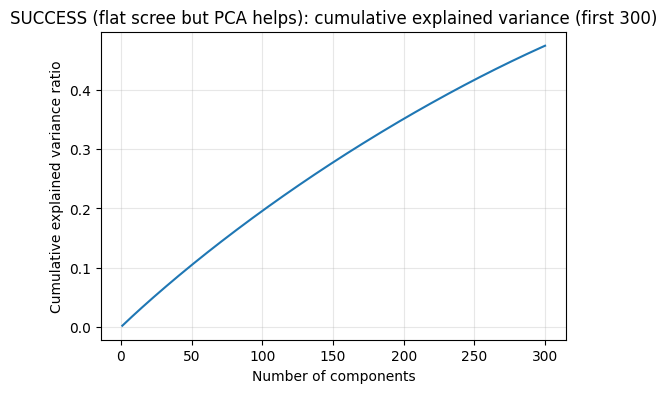

PCA(50) kNN(5) CV acc: 0.19933333333333336


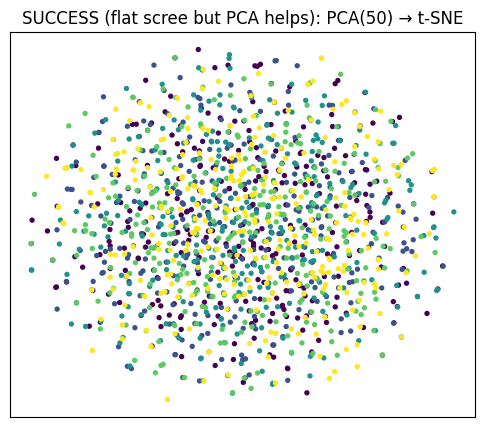


=== FAILURE (flat scree and PCA doesn't help) ===
Raw kNN(5) CV acc: 0.2053333333333333


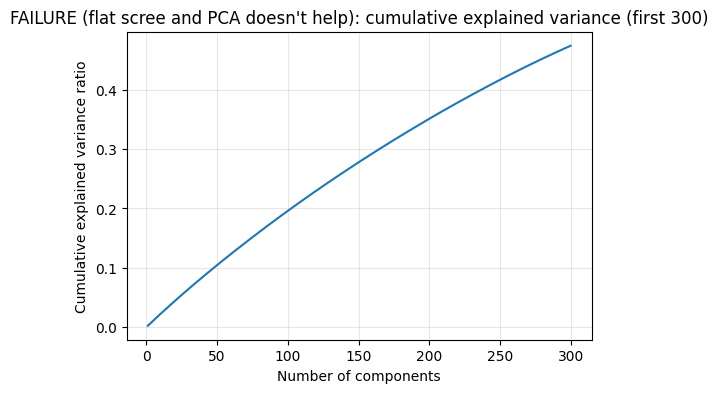

PCA(50) kNN(5) CV acc: 0.21400000000000002


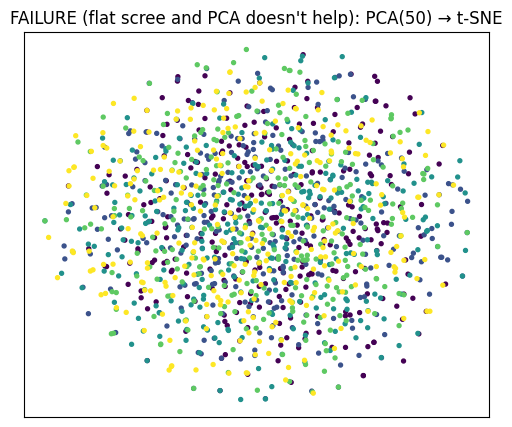

In [3]:


# --- experiment runner ---
def run_demo(X, y, name, pca_dim=50, tsne_perplexity=30, seed=0):
    print(f"\n=== {name} ===")
    print("Raw kNN(5) CV acc:", knn_cv_accuracy(X, y, k=5))

    # PCA fit
    pca_full = PCA(n_components=min(300, X.shape[1]), random_state=seed)
    pca_full.fit(X)
    plot_scree(pca_full, title=f"{name}: cumulative explained variance (first {pca_full.n_components_})")

    # PCA -> t-SNE
    pca = PCA(n_components=pca_dim, random_state=seed)
    Xp = pca.fit_transform(X)
    print(f"PCA({pca_dim}) kNN(5) CV acc:", knn_cv_accuracy(Xp, y, k=5))

    tsne = TSNE(n_components=2, perplexity=tsne_perplexity, init="pca",
                learning_rate="auto", random_state=seed)
    Z = tsne.fit_transform(Xp)
    plot_tsne(Z, y, title=f"{name}: PCA({pca_dim}) → t-SNE")

# --- generate and compare ---
X1, y1 = dataset_success_flat_scree(D=2000, r=30, noise_sigma=1.0, mean_scale=1.2, seed=0)
X2, y2 = dataset_failure_flat_scree(D=2000, noise_sigma=1.0, mean_scale=1.2, seed=1)

run_demo(X1, y1, "SUCCESS (flat scree but PCA helps)", pca_dim=50, tsne_perplexity=30, seed=0)
run_demo(X2, y2, "FAILURE (flat scree and PCA doesn't help)", pca_dim=50, tsne_perplexity=30, seed=0)


Text(0.5, 1.0, 'Unit Circle')

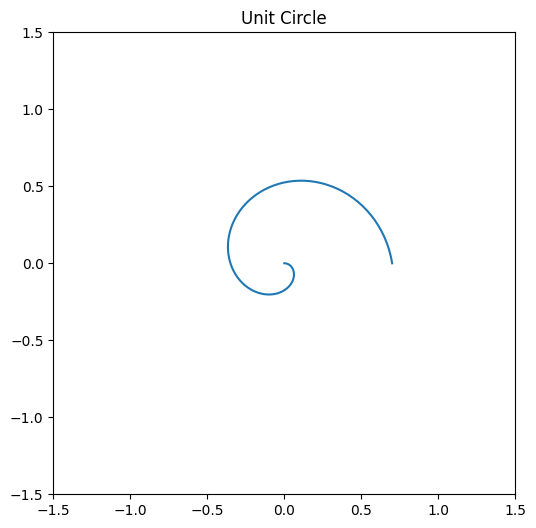

In [4]:
import numpy as np
import matplotlib.pyplot as plt

N = 100
t = np.linspace(0, 1, N)
shrink = 0.7
theta = 2 * np.pi * t
r = shrink * (1-t)

x = r * np.cos(theta)
y = r * np.sin(theta)

plt.figure(figsize=(6,6))
plt.plot(x, y, label='Circle')
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Unit Circle')

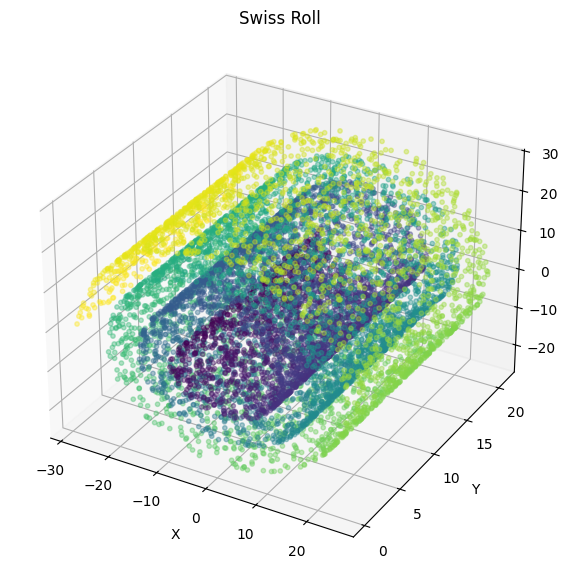

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# パラメータ設定
n_samples = 10000

# スイスロールの生成
t = 3 * np.pi * (1 + 2 * np.random.rand(n_samples))  # パラメータt（角度）
h = 21 * np.random.rand(n_samples)  # 高さ

# 3次元座標の計算
x = t * np.cos(t)
y = h
z = t * np.sin(t)

# 可視化
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c=t, cmap='viridis', s=10, alpha=0.4)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Swiss Roll')
plt.show()

Text(0.5, 0, 'Z')

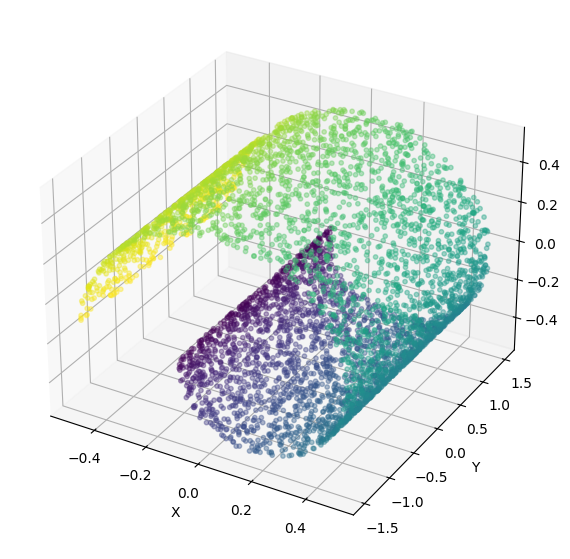

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# パラメータ設定
n_samples = 5000

# スイスロールの生成
t = 1 * np.pi * (1 + 2 * np.random.rand(n_samples))  # パラメータt（角度）
h = 21 * np.random.rand(n_samples)  # 高さ

# 3次元座標の計算
x = t * np.cos(t)
y = h
z = t * np.sin(t)

x -= x.min()
x /= x.max()
x -= 0.5
z -= z.min()
z /= z.max()
z -= 0.5
#y_aspect = 0.1  # y方向の比率調整
y_aspect = 3  # y方向の比率調整
y /= y.max() * 1/y_aspect  # y方向だけ比率を変える
y -= 0.5 * y_aspect
# 可視化
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c=t, cmap='viridis', s=10, alpha=0.4)
#ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

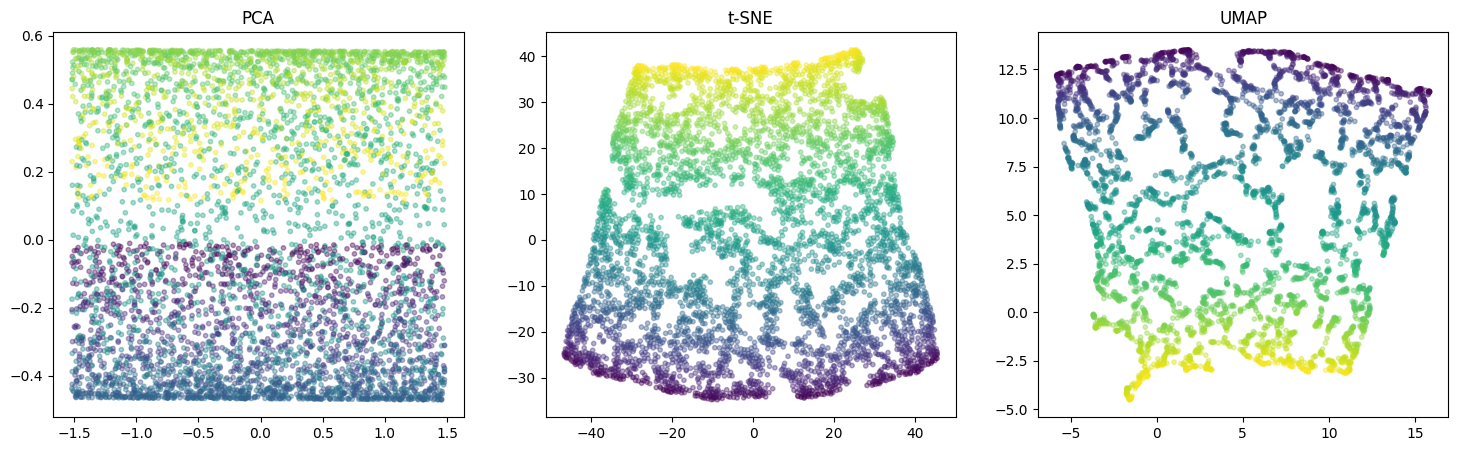

In [96]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

# PCAによる次元削減
pca = PCA(n_components=2)
X_pca = pca.fit_transform(np.column_stack((x, y, z)))

# t-SNEによる次元削減
tsne = TSNE(n_components=2, perplexity=80, random_state=0)
X_tsne = tsne.fit_transform(np.column_stack((x, y, z)))

# UMAPによる次元削減
umap = UMAP(n_components=2)
X_umap = umap.fit_transform(np.column_stack((x, y, z)))

# 可視化
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].scatter(X_pca[:, 0], X_pca[:, 1], c=t, cmap='viridis', s=10, alpha=0.4)
axs[0].set_title('PCA')
axs[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=t, cmap='viridis', s=10, alpha=0.4)
axs[1].set_title('t-SNE')
axs[2].scatter(X_umap[:, 0], X_umap[:, 1], c=t, cmap='viridis', s=10, alpha=0.4)
axs[2].set_title('UMAP')
plt.show()  



(5000, 5000)


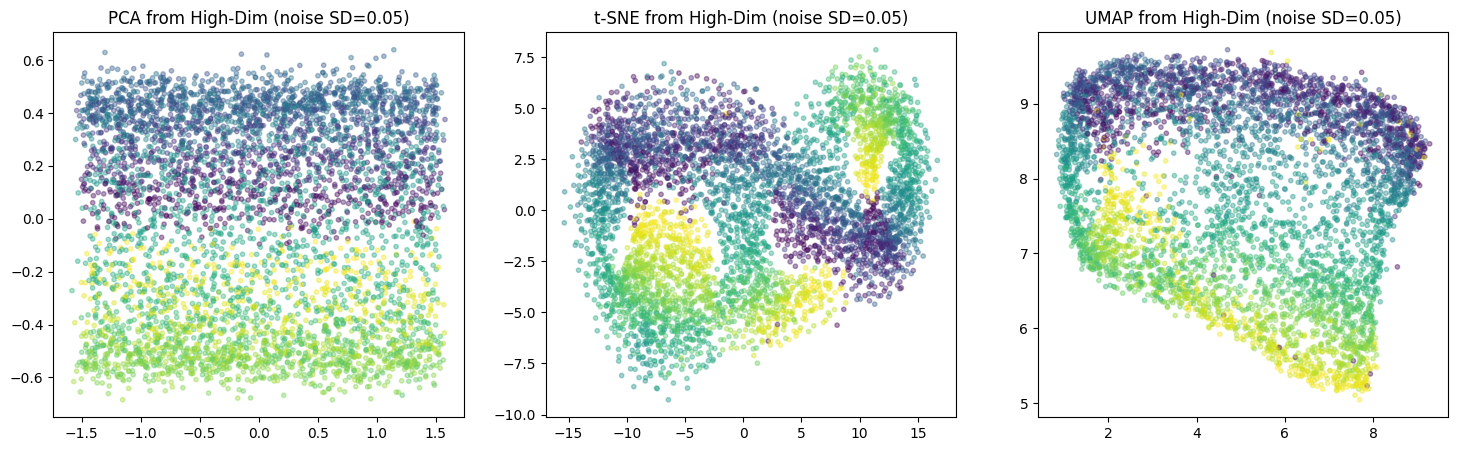

(5000, 5000)


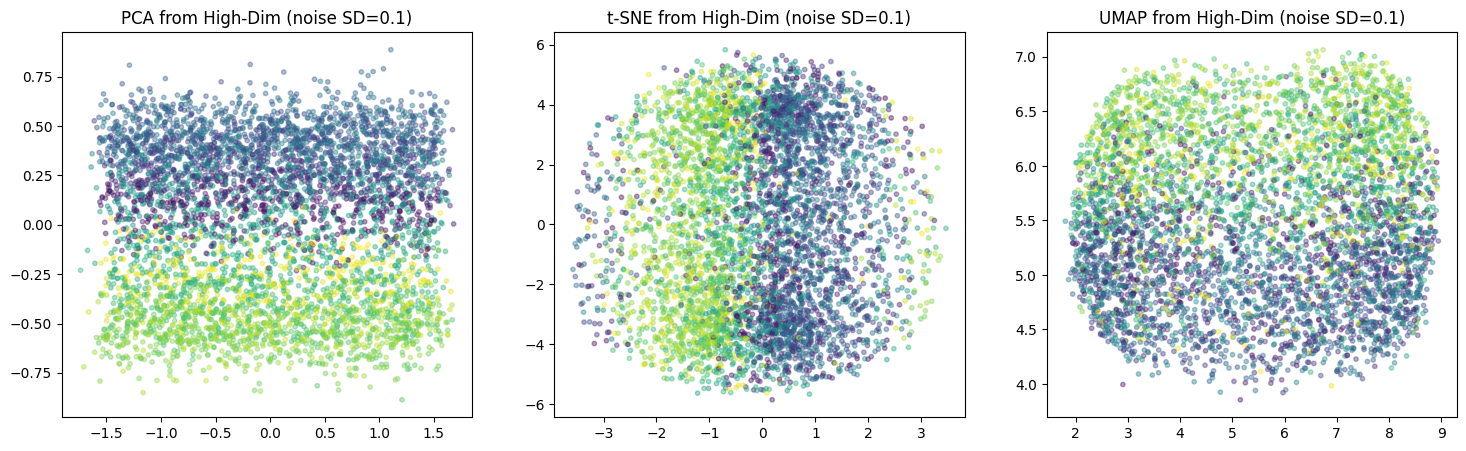

(5000, 5000)


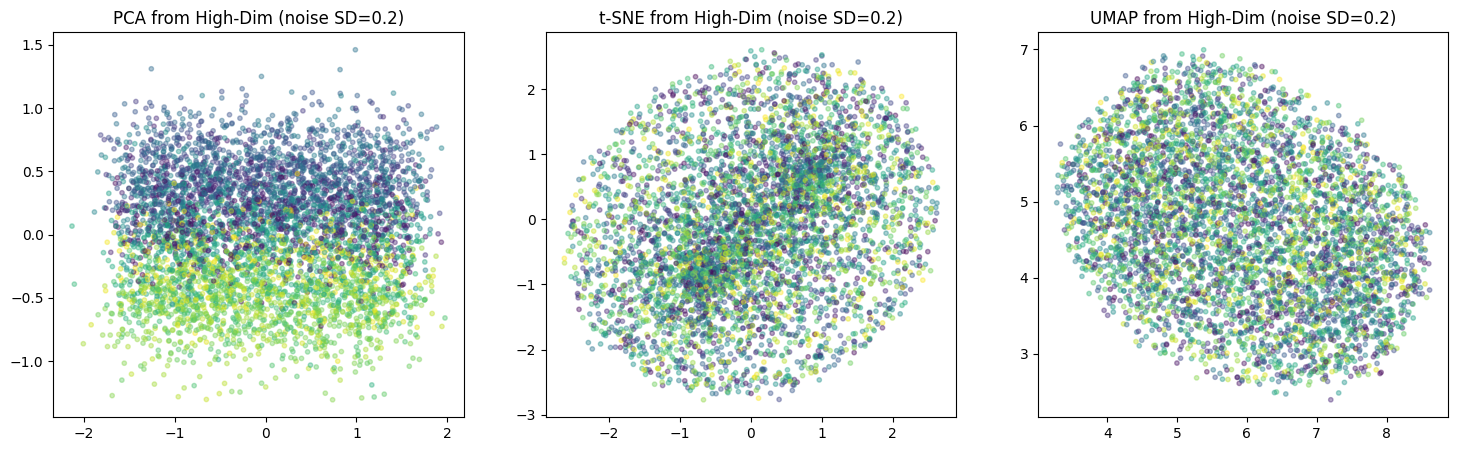

In [101]:
# さらに，この3次元を高次元空間に埋め込み，微小なノイズを加えてみる
D = 5000

SDs = [0.05, 0.1, 0.2]  # ノイズの標準偏差
X3 = np.column_stack((x, y, z))  # (n_samples, 3)

for sd in SDs:
    rng = np.random.default_rng(0)
    Q = rng.normal(size=(D, 3)) # (D, 3)
    Q, _ = np.linalg.qr(Q)  # 直交化, Q: (D, 3), Q.T @ Q = I
    X_high = X3 @ Q.T  # (n_samples, D)
    X_high += rng.normal(scale=sd, size=X_high.shape)  # 微小ノイズ付加

    print(X_high.shape)

    # PCAによる次元削減
    pca = PCA(n_components=2)
    X_pca_high = pca.fit_transform(X_high)

    # いきなりt-SNE
    tsne_high = TSNE(n_components=2, perplexity=80, random_state=0)
    X_tsne_high = tsne_high.fit_transform(X_high)

    # いきなりUMAP
    umap_high = UMAP(n_components=2)
    X_umap_high = umap_high.fit_transform(X_high)

    # 可視化
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    axs[0].scatter(X_pca_high[:, 0], X_pca_high[:, 1], c=t, cmap='viridis', s=10, alpha=0.4)
    axs[0].set_title(f'PCA from High-Dim (noise SD={sd})')
    axs[1].scatter(X_tsne_high[:, 0], X_tsne_high[:, 1], c=t, cmap='viridis', s=10, alpha=0.4)
    axs[1].set_title(f't-SNE from High-Dim (noise SD={sd})')
    axs[2].scatter(X_umap_high[:, 0], X_umap_high[:, 1], c=t, cmap='viridis', s=10, alpha=0.4)
    axs[2].set_title(f'UMAP from High-Dim (noise SD={sd})')
    plt.show()


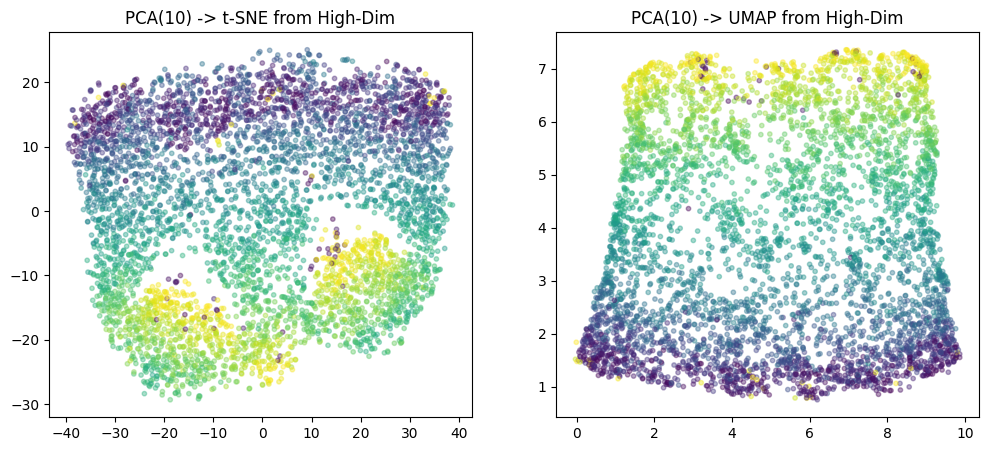

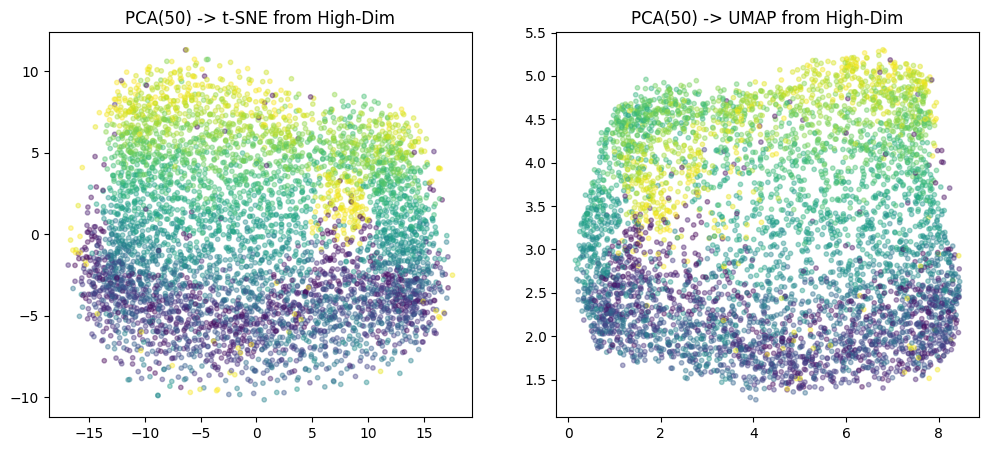

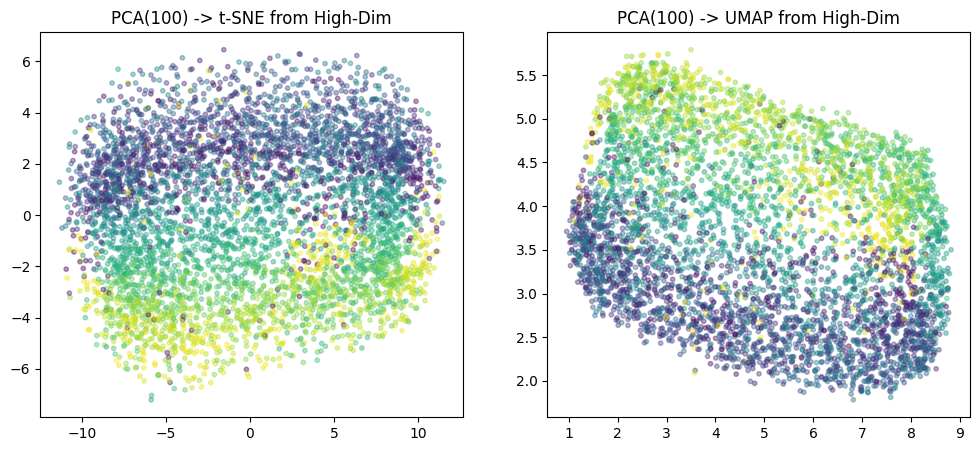

In [102]:
# じゃ，先に PCAで次元削減してから，t-SNEやUMAPを適用したらどうなるか？

D = 5000

sd = 0.1 # ノイズの標準偏差固定
X3 = np.column_stack((x, y, z))  # (n_samples, 3)
mid_dims = [10, 50, 100]  # PCAで削減する中間次元数

rng = np.random.default_rng(0)
Q = rng.normal(size=(D, 3)) # (D, 3)
Q, _ = np.linalg.qr(Q)  # 直交化, Q: (D, 3), Q.T @ Q = I
X_high = X3 @ Q.T  # (n_samples, D)
X_high += rng.normal(scale=sd, size=X_high.shape)  # 微小ノイズ付加


for mid_dim in mid_dims:
    pca_mid = PCA(n_components=mid_dim)
    X_mid = pca_mid.fit_transform(X_high)

    # PCA -> t-SNE
    tsne_mid = TSNE(n_components=2, perplexity=80, random_state=42)
    X_tsne_mid = tsne_mid.fit_transform(X_mid)

    # PCA -> UMAP
    umap_mid = UMAP(n_components=2)
    X_umap_mid = umap_mid.fit_transform(X_mid)

    # 可視化
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].scatter(X_tsne_mid[:, 0], X_tsne_mid[:, 1], c=t, cmap='viridis', s=10, alpha=0.4)
    axs[0].set_title(f'PCA({mid_dim}) -> t-SNE from High-Dim')
    axs[1].scatter(X_umap_mid[:, 0], X_umap_mid[:, 1], c=t, cmap='viridis', s=10, alpha=0.4)
    axs[1].set_title(f'PCA({mid_dim}) -> UMAP from High-Dim')
    plt.show()

[-3.09000475 -0.79848634]


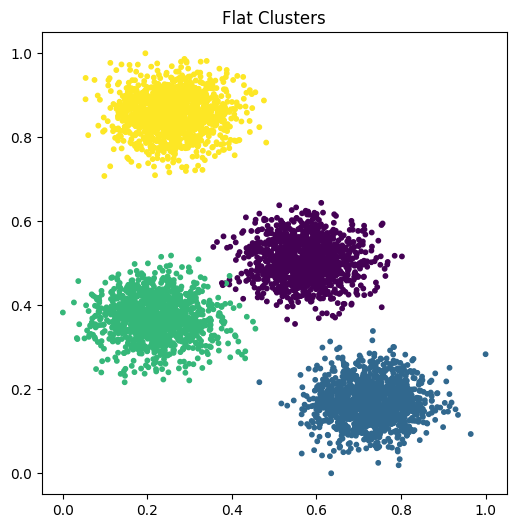

In [36]:
from sklearn.datasets import make_blobs

n_samples = 5000
n_clusters = 4
c_std = 0.5

X_flat, true_labels = make_blobs(n_samples=n_samples, centers=n_clusters, cluster_std=c_std, random_state=0)

print(np.min(X_flat, axis=0))
X_flat -= np.min(X_flat, axis=0) # 全体を正の領域にシフト
X_flat /= np.max(X_flat, axis=0) # [0,1]に正規化

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(X_flat[:,0], X_flat[:,1], c=true_labels, s=10, cmap='viridis')
ax.set_title('Flat Clusters')
plt.show()


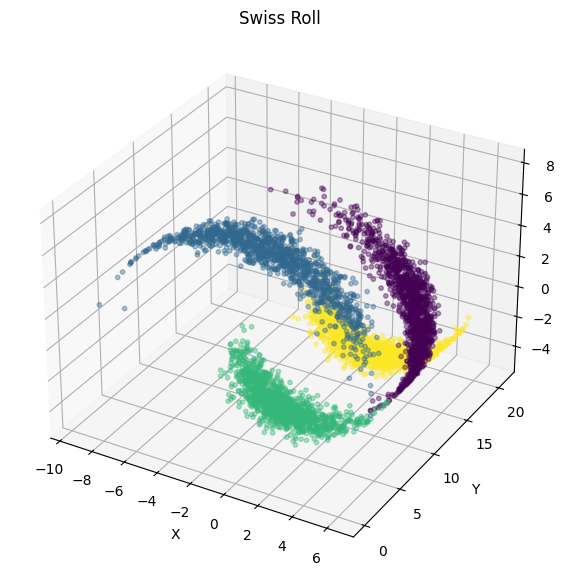

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_blobs

# パラメータ設定

# スイスロールの生成
t = 1 * np.pi * (1 + 2 * X_flat[:, 0])  # パラメータt（角度）
h = 21 * X_flat[:, 1]  # 高さ

# 3次元座標の計算
x = t * np.cos(t)
y = h
z = t * np.sin(t)

# 可視化
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c=true_labels, s=10, alpha=0.4)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Swiss Roll')
plt.show()